# Importation de Librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement du dataset 
pcos_extended_dataset.csv

In [3]:
df = pd.read_csv("../data/PCOS_extended_dataset.csv")
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (2000, 44)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


## Infos Générales

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3    Age (yrs)              2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   

## Statistiques descriptives

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl. No,2000.0,266.633000,154.058467,1.000000,132.000000,267.000000,395.000000,541.000000
Patient File No.,2000.0,266.633000,154.058467,1.000000,132.000000,267.000000,395.000000,541.000000
PCOS (Y/N),2000.0,0.304000,0.460098,0.000000,0.000000,0.000000,1.000000,1.000000
Age (yrs),2000.0,31.354000,5.449820,20.000000,28.000000,31.000000,35.000000,48.000000
Weight (Kg),2000.0,59.527068,11.445212,30.739215,52.248684,58.538632,65.519518,113.379053
Height(Cm),2000.0,156.416496,6.044243,136.539081,152.169130,156.433674,160.064790,180.388539
BMI,2000.0,24.284184,4.132187,11.939138,21.765743,24.188981,26.600461,40.449415
Blood Group,2000.0,13.788000,1.832958,11.000000,13.000000,14.000000,15.000000,18.000000
Pulse rate(bpm),2000.0,73.241000,4.098941,13.000000,72.000000,72.000000,74.000000,82.000000
RR (breaths/min),2000.0,19.232000,1.740601,16.000000,18.000000,18.000000,20.000000,28.000000


## Valeurs manquantes

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Marraige Status (Yrs)    3
dtype: int64

## Distribution de la cible 

C:\Users\yasmi\AppData\Local\Temp\ipykernel_25900\118818757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="PCOS (Y/N)", data=df, palette=["#4C72B0", "#DD8452"])
C:\Users\yasmi\AppData\Local\Temp\ipykernel_25900\118818757.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-PCOS (N)", "PCOS (Y)"])


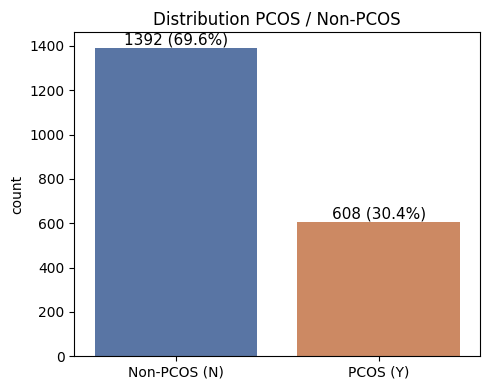

In [14]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="PCOS (Y/N)", data=df, palette=["#4C72B0", "#DD8452"])
ax.set_title("Distribution PCOS / Non-PCOS")
ax.set_xlabel("")
ax.set_xticklabels(["Non-PCOS (N)", "PCOS (Y)"])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

## Heatmap corrélations

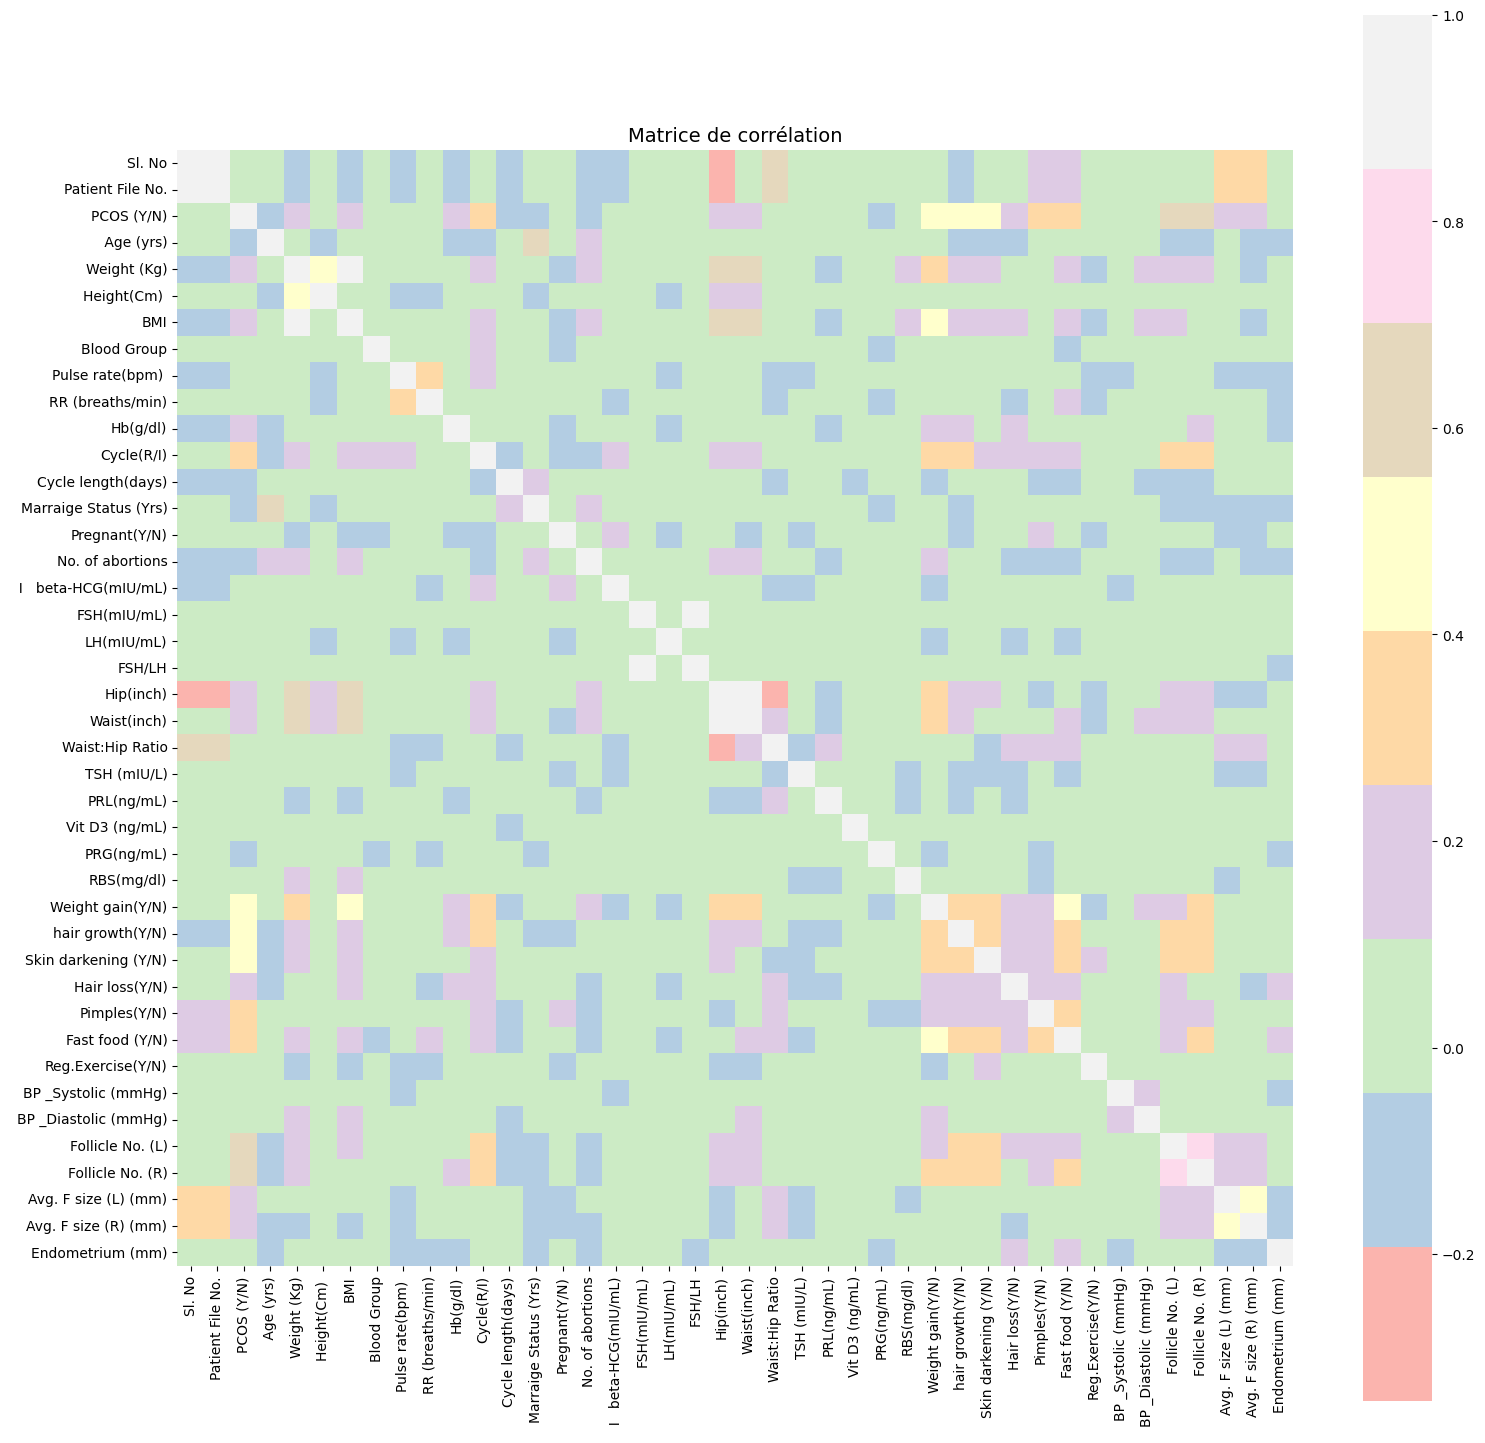

In [24]:
data = df.copy()
data = data.select_dtypes(include=['int64', 'float64'])

corrmat = data.corr()

plt.subplots(figsize=(18, 18))
sns.heatmap(corrmat, cmap='Pastel1', square=True)
plt.title('Matrice de corrélation', fontsize=14)
plt.show()

* Corrélations avec PCOS (Y/N) triées par ordre décroissant

In [25]:
corrmat['PCOS (Y/N)'].sort_values(ascending=False)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.634140
Follicle No. (L)          0.599351
hair growth(Y/N)          0.482538
Skin darkening (Y/N)      0.466360
Weight gain(Y/N)          0.431333
Cycle(R/I)                0.398291
Fast food (Y/N)           0.384289
Pimples(Y/N)              0.278531
Weight (Kg)               0.221852
BMI                       0.204274
Waist(inch)               0.193944
Hair loss(Y/N)            0.182375
Hip(inch)                 0.178463
Hb(g/dl)                  0.126089
Avg. F size (L) (mm)      0.122394
Avg. F size (R) (mm)      0.106656
LH(mIU/mL)                0.091386
Pulse rate(bpm)           0.082620
Height(Cm)                0.073486
Reg.Exercise(Y/N)         0.068214
Endometrium (mm)          0.066357
Vit D3 (ng/mL)            0.066113
Sl. No                    0.065085
Patient File No.          0.065085
RR (breaths/min)          0.059307
RBS(mg/dl)                0.049778
BP _Diastolic (mmHg)      0.047691
Waist:Hip Ratio     

## Heatmap des features les plus significatives (positives + négatives)

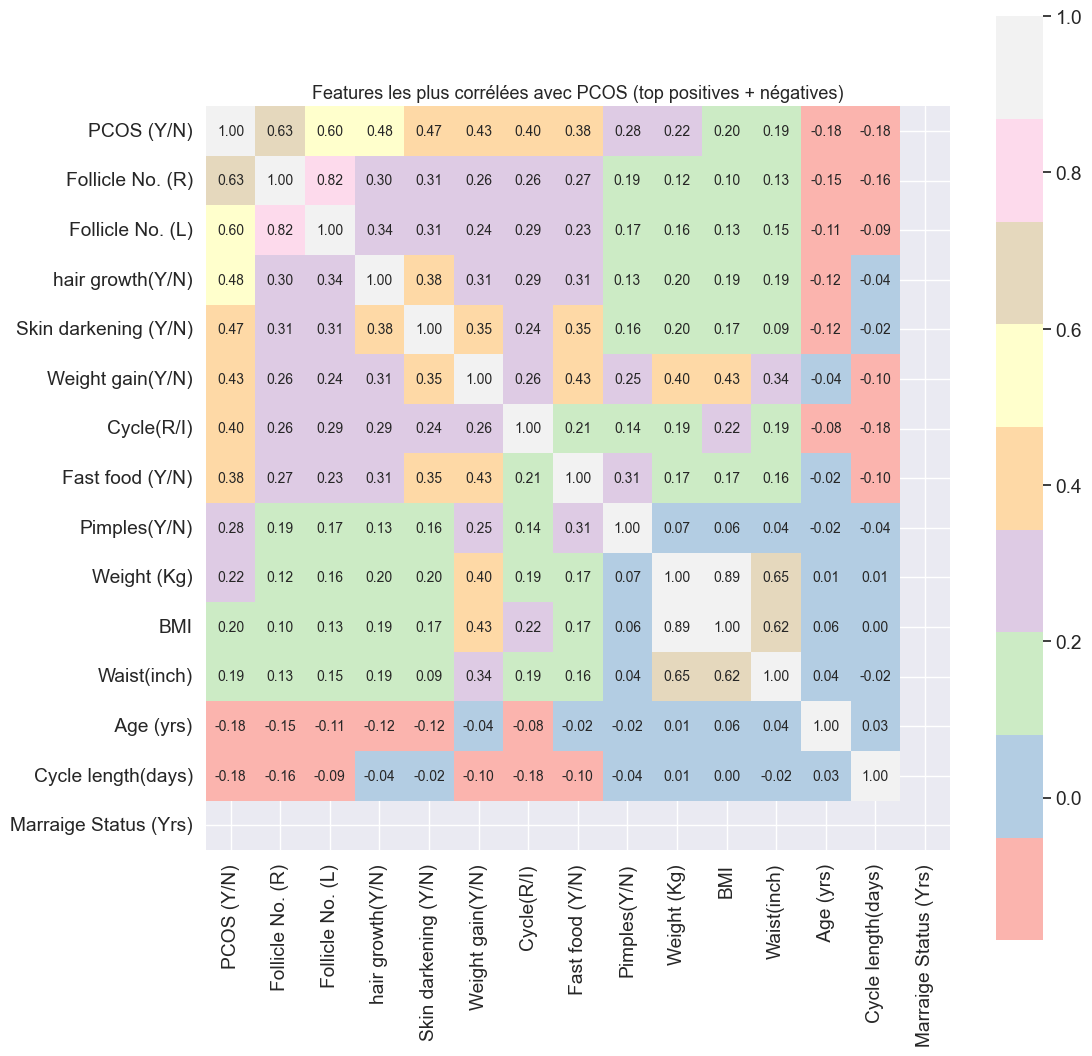

In [ ]:
plt.figure(figsize=(12, 12))

k = 12  
l = 3    

cols_p = corrmat.nlargest(k, 'PCOS (Y/N)')['PCOS (Y/N)'].index
cols_n = corrmat.nsmallest(l, 'PCOS (Y/N)')['PCOS (Y/N)'].index
cols   = cols_p.append(cols_n)

cm = np.corrcoef(data[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, cmap='Pastel1', annot=True, square=True,
                 fmt='.2f', annot_kws={'size': 10},
                 yticklabels=cols.values,
                 xticklabels=cols.values)
plt.title('Features les plus corrélées avec PCOS (top positives + négatives)', fontsize=13)
plt.show()

## Distribution des features cliniques clés

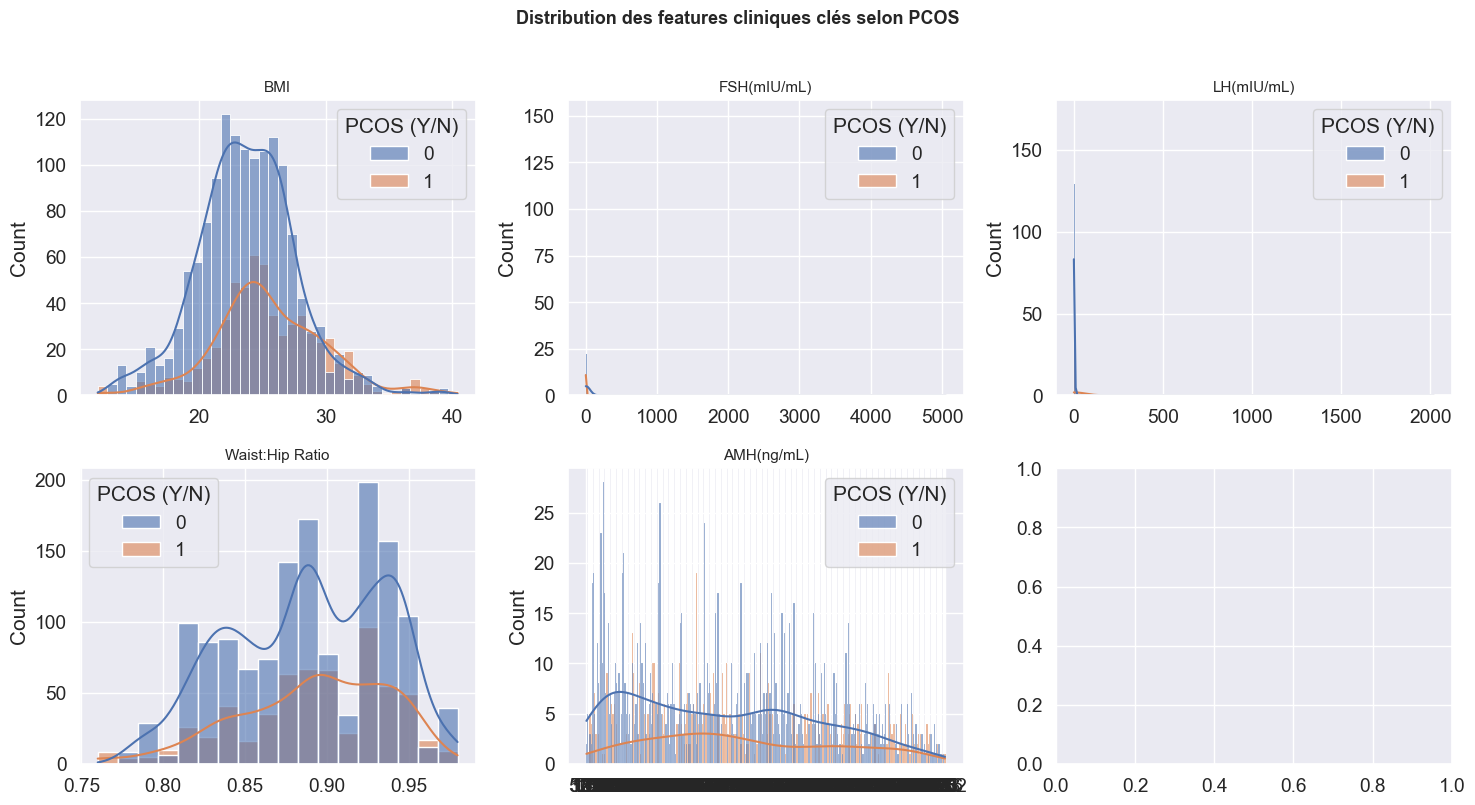

In [ ]:
features_cles = ['BMI', 'Age (yrs)', 'FSH(mIU/mL)', 'LH(mIU/mL)',
                 'Waist:Hip Ratio', 'AMH(ng/mL)']
features_cles = [f for f in features_cles if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_cles):
    sns.histplot(data=df, x=feat, hue='PCOS (Y/N)',
                 kde=True, ax=axes[i],
                 alpha=0.6)         
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Distribution des features cliniques clés selon PCOS',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Boxplots : PCOS vs Non-PCOS

C:\Users\yasmi\AppData\Local\Temp\ipykernel_25900\700117882.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels())  # garde les labels existants
C:\Users\yasmi\AppData\Local\Temp\ipykernel_25900\700117882.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels())  # garde les labels existants
C:\Users\yasmi\AppData\Local\Temp\ipykernel_25900\700117882.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels())  # garde les labels existants
C:\Users\yasmi\AppData\Local\Temp\ipykernel_25900\700117882.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

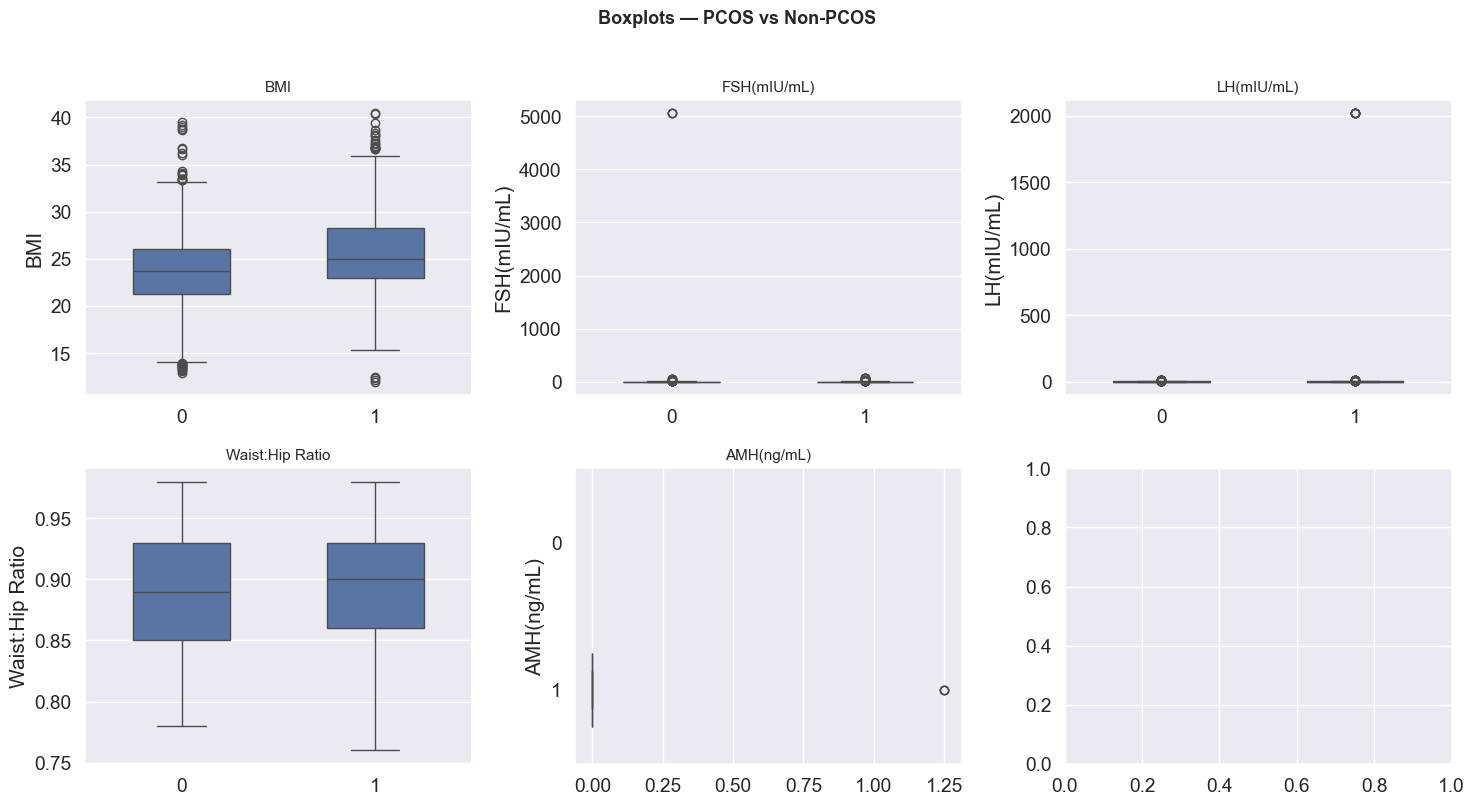

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_cles):
    sns.boxplot(data=df, x='PCOS (Y/N)', y=feat,
                ax=axes[i], width=0.5,
                order=df['PCOS (Y/N)'].unique())
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels()) 

plt.suptitle('Boxplots — PCOS vs Non-PCOS', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Pairplot des top 4 features les plus corrélées

Valeurs dans PCOS (Y/N) : [0 1]


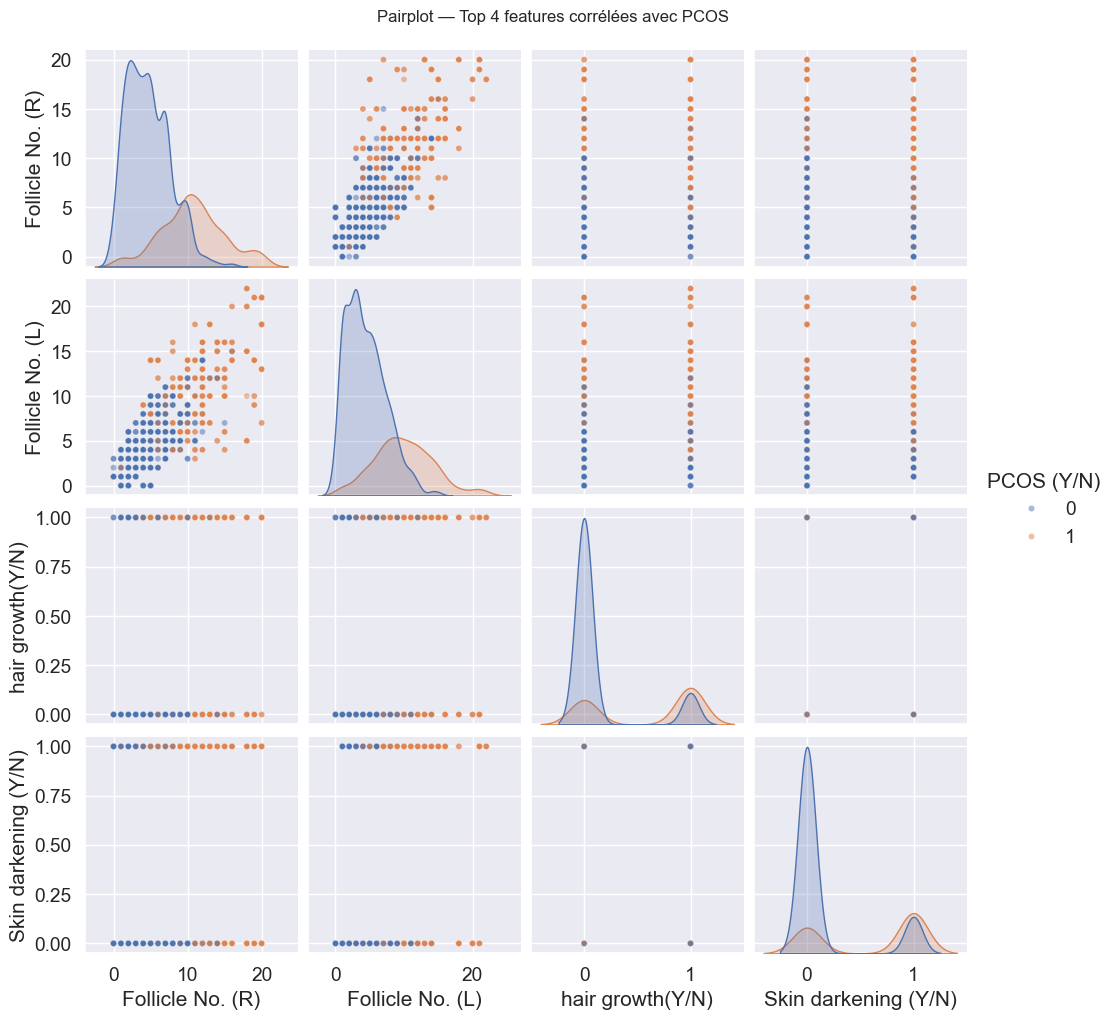

In [ ]:
top4 = list(
    corrmat['PCOS (Y/N)'].drop('PCOS (Y/N)')
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
)
cols_pairplot = [c for c in top4 + ['PCOS (Y/N)'] if c in df.columns]

valeurs = df['PCOS (Y/N)'].unique()
print(f"Valeurs dans PCOS (Y/N) : {valeurs}")

couleurs = ['#4C72B0', '#DD8452']
palette_auto = {val: couleurs[i] for i, val in enumerate(sorted(valeurs))}

sns.pairplot(df[cols_pairplot], hue='PCOS (Y/N)',
             palette=palette_auto,
             plot_kws={'alpha': 0.5, 's': 20},
             diag_kind='kde')
plt.suptitle('Pairplot — Top 4 features corrélées avec PCOS',
             fontsize=12, y=1.02)
plt.show()

# Résumé

In [38]:
top_feat = corrmat['PCOS (Y/N)'].drop('PCOS (Y/N)').abs().sort_values(ascending=False)

print('_' * 55)
print('           EDA')
print('_' * 55)
print(f'  Nombre de lignes          : {df.shape[0]}')
print(f'  Nombre de colonnes        : {df.shape[1]}')
print(f'  Cas PCOS (Y)              : {(df["PCOS (Y/N)"] == 1).sum()}')
print(f'  Cas Non-PCOS (N)          : {(df["PCOS (Y/N)"] == 0).sum()}')
print(f'  Colonnes avec NaN         : {df.isnull().any().sum()}')
print(f'  Total valeurs manquantes  : {df.isnull().sum().sum()}')
print(f'  Doublons                  : {df.duplicated().sum()}')
print(f'  Feature la + corrélée     : {top_feat.index[0]} ({top_feat.values[0]:.3f})')
print('_' * 55)


_______________________________________________________
           EDA
_______________________________________________________
  Nombre de lignes          : 2000
  Nombre de colonnes        : 44
  Cas PCOS (Y)              : 608
  Cas Non-PCOS (N)          : 1392
  Colonnes avec NaN         : 1
  Total valeurs manquantes  : 3
  Doublons                  : 0
  Feature la + corrélée     : Follicle No. (R) (0.634)
_______________________________________________________
